In [11]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import random
import cv2
import splitfolders
import pandas as pd


In [12]:
IMAGES_FOLDERS_PATH = './PlantVillage'
OUTPUT_FOLDER = 'plantdisease_split'
WIDTH = 224
HEIGHT = 224
CHANNELS = 3


Image distribution across classes:
                                      Class  Count
      Tomato__Tomato_YellowLeaf__Curl_Virus   3209
                      Tomato_Bacterial_spot   2127
                         Tomato_Late_blight   1909
                  Tomato_Septoria_leaf_spot   1771
Tomato_Spider_mites_Two_spotted_spider_mite   1676
                             Tomato_healthy   1591
                     Pepper__bell___healthy   1478
                        Tomato__Target_Spot   1404
                      Potato___Early_blight   1000
                       Potato___Late_blight   1000
                        Tomato_Early_blight   1000
              Pepper__bell___Bacterial_spot    994
                           Tomato_Leaf_Mold    952
                Tomato__Tomato_mosaic_virus    373
                           Potato___healthy    152


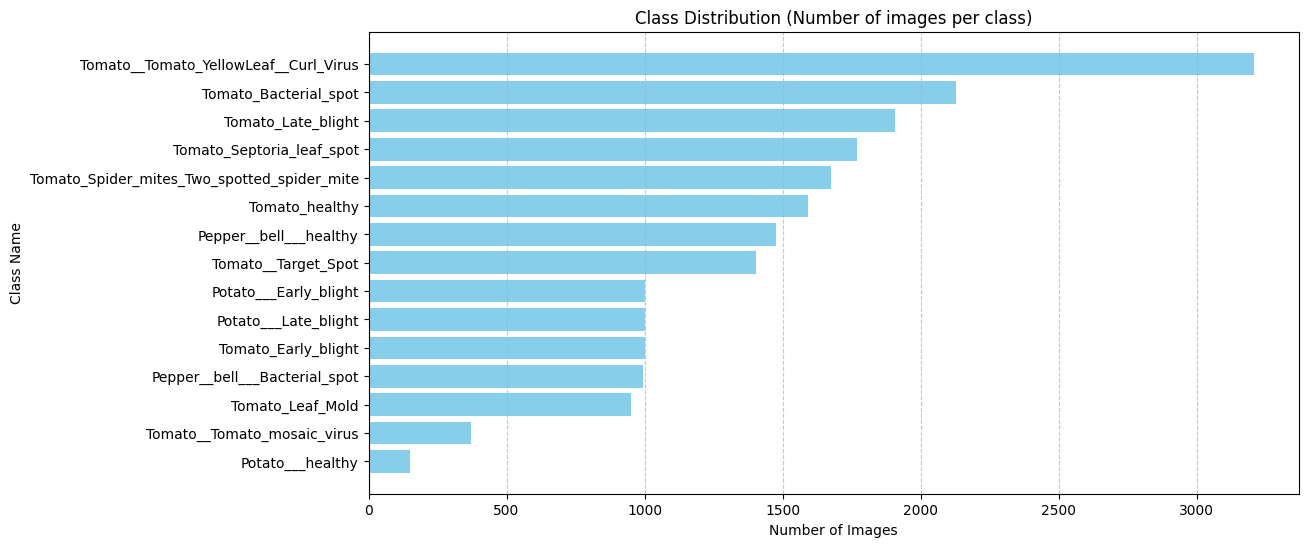

In [13]:
data = []
for class_name in os.listdir(IMAGES_FOLDERS_PATH):
    class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        data.append({'Class': class_name, 'Count': count})

df_dist = pd.DataFrame(data).sort_values(by='Count', ascending=False)

print("Image distribution across classes:")
print(df_dist.to_string(index=False))

plt.figure(figsize=(12, 6))
plt.barh(df_dist['Class'], df_dist['Count'], color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.title('Class Distribution (Number of images per class)')
plt.gca().invert_yaxis()  
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Classes Number: 15


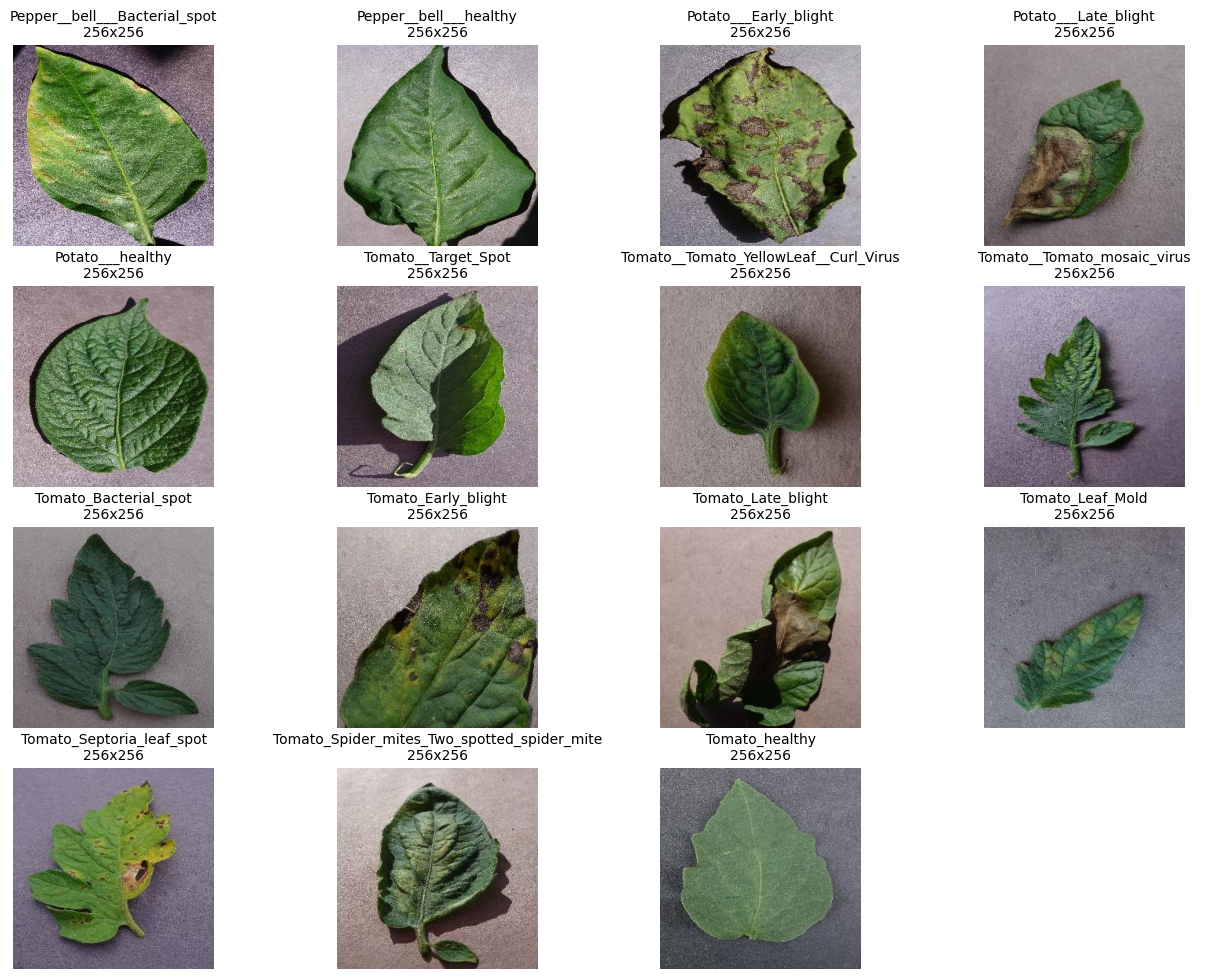

In [14]:
def VisualizeClasses(folders_path):
    # Get all class folders and sort them
    ClassesNames = os.listdir(folders_path)
    ClassesNames.sort(key=lambda x: (x.split('__')[0], x))
    
    # Display the total number of classes
    NUM_CLASSES = len(ClassesNames)
    print(f"Classes Number: {NUM_CLASSES}")
    
    cols = 4
    rows = (NUM_CLASSES + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3))
    axes = axes.flatten()
    
    # Show one sample image from each class
    for i, cat in enumerate(ClassesNames):
        ClassFolderPath = os.path.join(folders_path,cat)
        ImagesName = os.listdir(ClassFolderPath)
        img_path = os.path.join(ClassFolderPath,ImagesName[0])
        with Image.open(img_path) as img:
            width, height = img.size
        image = mpimg.imread(img_path)
        axes[i].imshow(image)
        axes[i].set_title(f"{cat}\n{width}x{height}", fontsize=10)
        axes[i].axis('off')
        
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

VisualizeClasses(IMAGES_FOLDERS_PATH) 

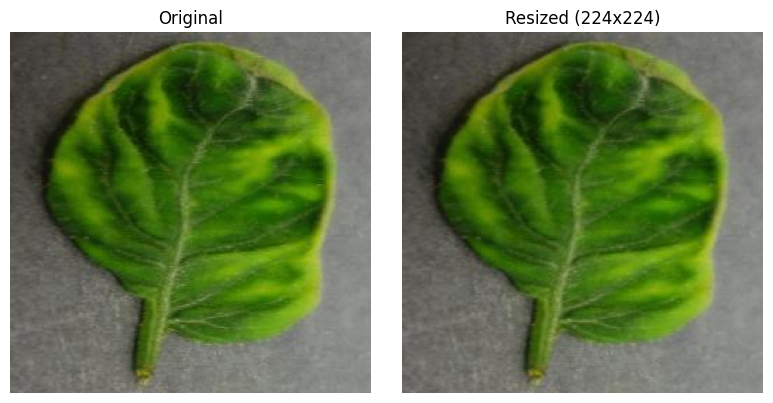

In [15]:
# Pick a random class folder
ClassesNames = os.listdir(IMAGES_FOLDERS_PATH)
random_class = random.choice(ClassesNames)
class_path = os.path.join(IMAGES_FOLDERS_PATH, random_class)

# Pick a random image from that class
images = os.listdir(class_path)
random_image = random.choice(images)
img_path = os.path.join(class_path, random_image)

# Open and resize the selected image to 224x224
with Image.open(img_path) as img:
    resized_img = img.resize((WIDTH, HEIGHT)) 

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mpimg.imread(img_path))
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(resized_img)
axes[1].set_title(f"Resized ({WIDTH}x{HEIGHT})")
axes[1].axis('off')

plt.tight_layout()
plt.show()

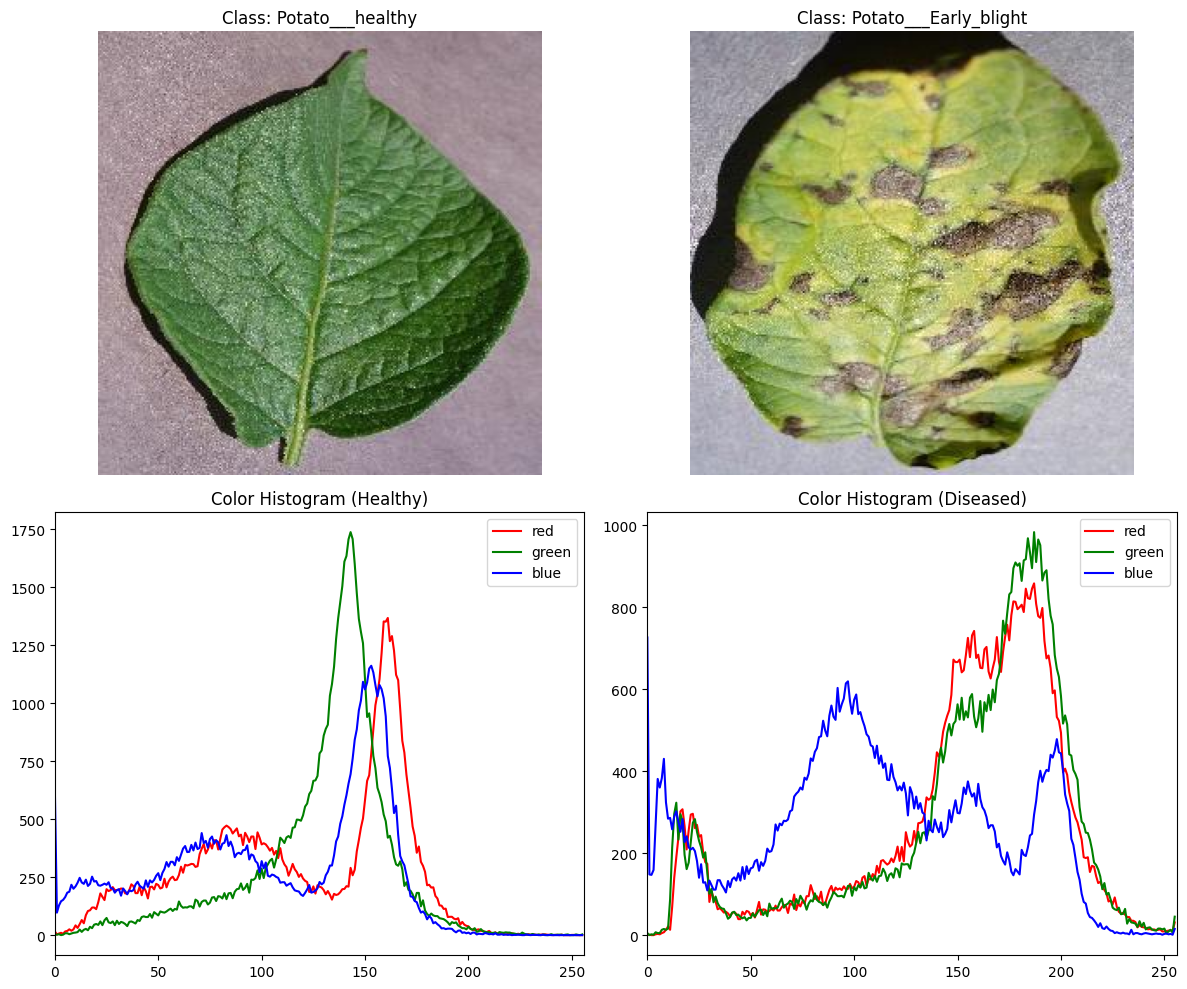

In [16]:
def plot_healthy_vs_diseased(plant_name):
    all_classes = [d for d in os.listdir(IMAGES_FOLDERS_PATH) if d.startswith(plant_name)]
    
    healthy_class = [c for c in all_classes if 'healthy' in c.lower()]
    diseased_classes = [c for c in all_classes if 'healthy' not in c.lower()]
    
    if not healthy_class or not diseased_classes:
        print(f"Couldn't find both healthy and diseased for {plant_name}")
        return

    target_diseased = random.choice(diseased_classes)
    target_healthy = healthy_class[0]

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    for i, class_name in enumerate([target_healthy, target_diseased]):
        class_path = os.path.join(IMAGES_FOLDERS_PATH, class_name)
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)
        
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        
        axes[0, i].imshow(img_rgb)
        axes[0, i].set_title(f"Class: {class_name}")
        axes[0, i].axis('off')
        
        colors = ('red', 'green', 'blue')
        for j, col in enumerate(colors):
            hist = cv2.calcHist([img_rgb], [j], None, [256], [0, 256])
            axes[1, i].plot(hist, color=col, label=col)
            axes[1, i].set_xlim([0, 256])
            
        axes[1, i].set_title(f"Color Histogram ({'Healthy' if i==0 else 'Diseased'})")
        axes[1, i].legend()

    plt.tight_layout()
    plt.show()

plot_healthy_vs_diseased('Potato')

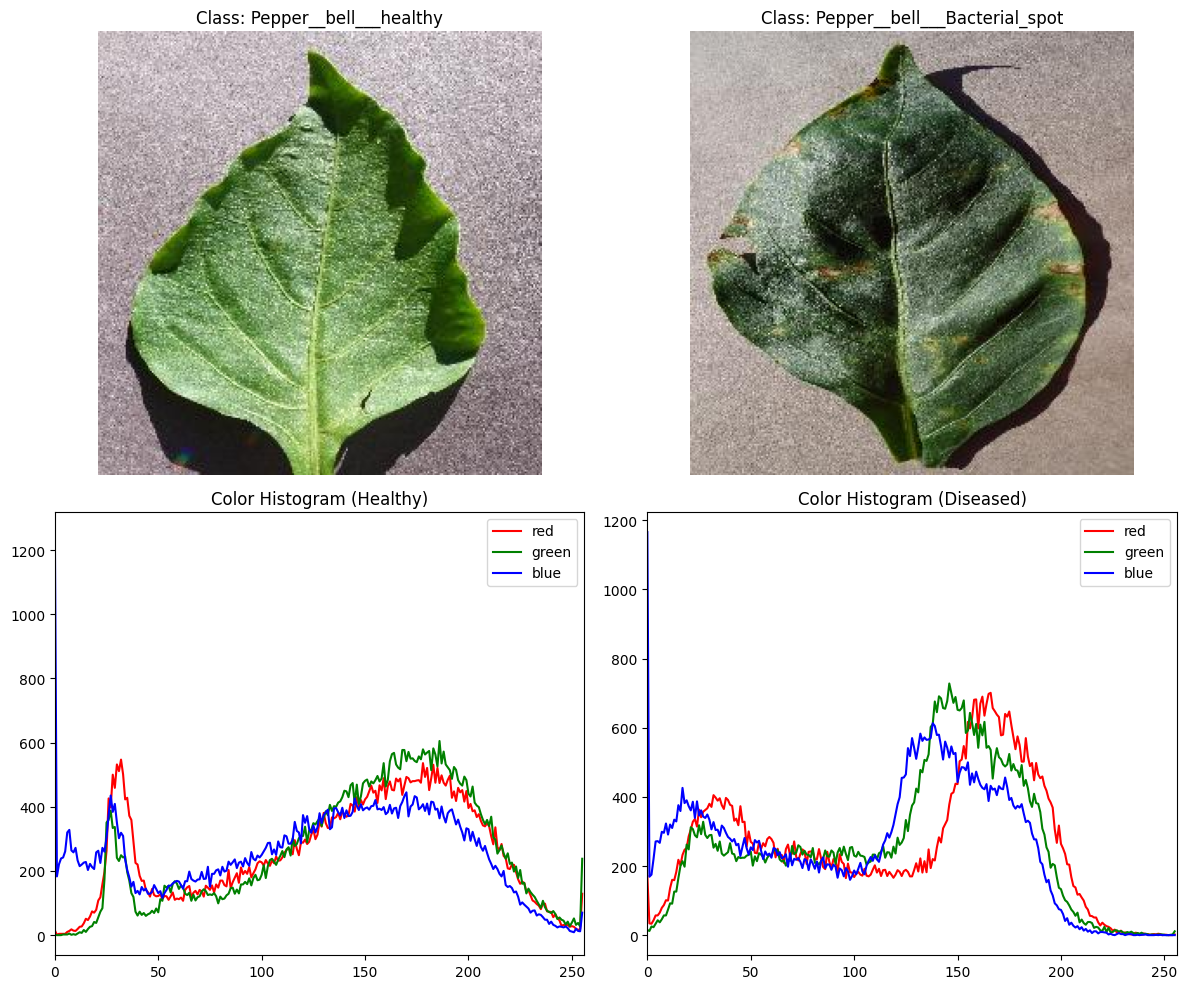

In [17]:
plot_healthy_vs_diseased('Pepper')

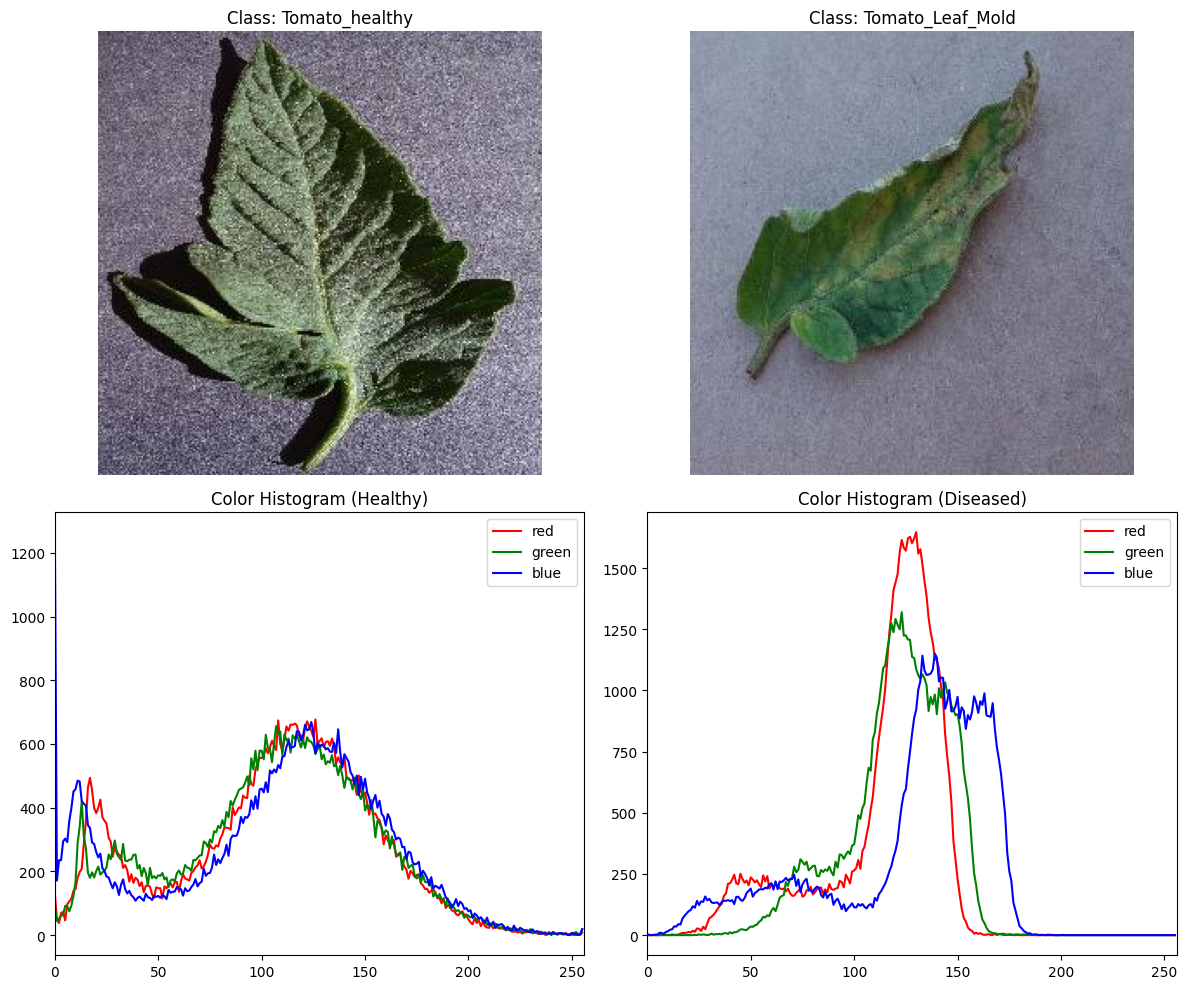

In [18]:
plot_healthy_vs_diseased('Tomato')

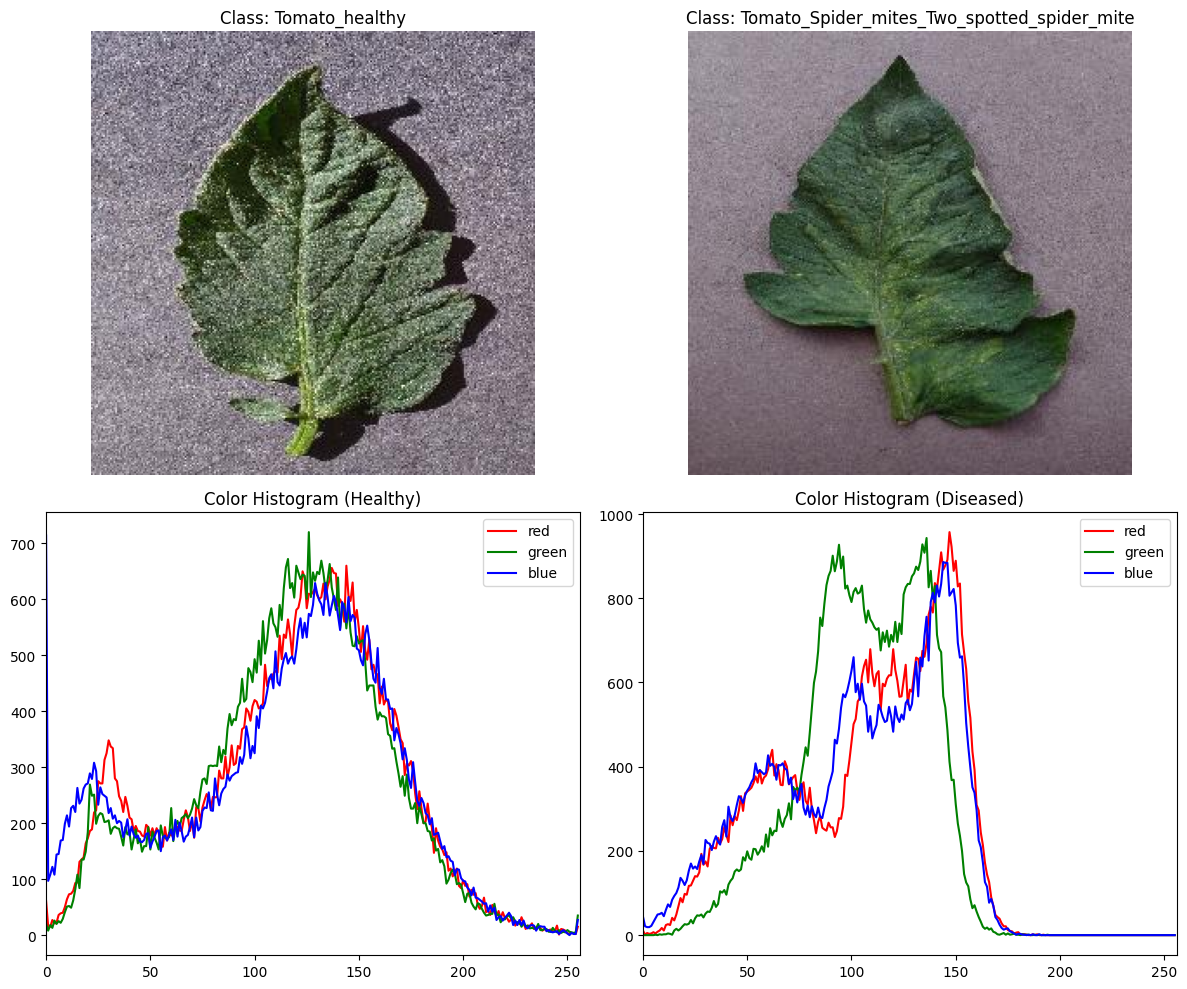

In [19]:
plot_healthy_vs_diseased('Tomato')

In [ ]:
splitfolders.ratio(IMAGES_FOLDERS_PATH, output=OUTPUT_FOLDER, seed=42, ratio=(0.8, 0.2))